In [3]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    roc_curve,
    auc
)

In [4]:
print("Loading dataset...")
dataset = load_dataset("shahxeebhassan/human_vs_ai_sentences")
data = dataset["train"]

# Use max 5000 samples
if len(data) > 5000:
    data = data.shuffle(seed=42).select(range(5000))

print("Total samples:", len(data))

Loading dataset...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

complete_dataset.csv:   0%|          | 0.00/12.7M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/105000 [00:00<?, ? examples/s]

Total samples: 5000


In [5]:
train_test = data.train_test_split(test_size=0.30, seed=42)
test_valid = train_test["test"].train_test_split(test_size=0.50, seed=42)

train_ds = train_test["train"]
val_ds   = test_valid["train"]
test_ds  = test_valid["test"]

print("Train:", len(train_ds), "Val:", len(val_ds), "Test:", len(test_ds))

Train: 3500 Val: 750 Test: 750


In [6]:
tokenizer = AutoTokenizer.from_pretrained("microsoft/deberta-base")

def tokenize(batch):
    return tokenizer(
        batch["text"],
        padding="max_length",
        truncation=True,
        max_length=128
    )

train_ds = train_ds.map(tokenize, batched=True)
val_ds   = val_ds.map(tokenize, batched=True)
test_ds  = test_ds.map(tokenize, batched=True)

train_ds.set_format("torch", columns=["input_ids", "attention_mask", "label"])
val_ds.set_format("torch", columns=["input_ids", "attention_mask", "label"])
test_ds.set_format("torch", columns=["input_ids", "attention_mask", "label"])

tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/474 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/3500 [00:00<?, ? examples/s]

Map:   0%|          | 0/750 [00:00<?, ? examples/s]

Map:   0%|          | 0/750 [00:00<?, ? examples/s]

In [7]:
model = AutoModelForSequenceClassification.from_pretrained(
    "microsoft/deberta-base",
    num_labels=2
)


def compute_metrics(pred):
    labels = pred.label_ids
    preds = np.argmax(pred.predictions, axis=1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, preds, average="binary"
    )
    acc = accuracy_score(labels, preds)

    return {
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

pytorch_model.bin:   0%|          | 0.00/559M [00:00<?, ?B/s]

Some weights of DebertaForSequenceClassification were not initialized from the model checkpoint at microsoft/deberta-base and are newly initialized: ['classifier.bias', 'classifier.weight', 'pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [8]:
training_args = TrainingArguments(
    output_dir="./deberta_output",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    report_to="none",
    logging_strategy="steps",
    logging_steps=50,
    disable_tqdm=False
)

In [9]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics
)

/tmp/ipython-input-4015516837.py:1: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


In [10]:
print("\nStarting training...\n")
trainer.train()
print("\nTraining finished!")

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 2, 'bos_token_id': 1}.



Starting training...



Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.302500,0.335606,0.874667,0.808656,0.972603,0.883085
2,0.196000,0.441622,0.892000,0.836493,0.967123,0.897078
3,0.096200,0.461391,0.902667,0.854369,0.964384,0.906049



Training finished!


In [11]:
print("\n===== DeBERTa TEST METRICS =====")
results = trainer.evaluate(test_ds)

print(f"Accuracy : {results['eval_accuracy']:.4f}")
print(f"Precision: {results['eval_precision']:.4f}")
print(f"Recall   : {results['eval_recall']:.4f}")
print(f"F1 Score : {results['eval_f1']:.4f}")


===== DeBERTa TEST METRICS =====


Accuracy : 0.8907
Precision: 0.8333
Recall   : 0.9759
F1 Score : 0.8990


In [12]:
pred_output = trainer.predict(test_ds)

y_true = pred_output.label_ids
logits = pred_output.predictions
y_pred = np.argmax(logits, axis=1)
y_prob = torch.softmax(torch.tensor(logits), dim=1)[:, 1].numpy()


Confusion Matrix:
[[303  73]
 [  9 365]]


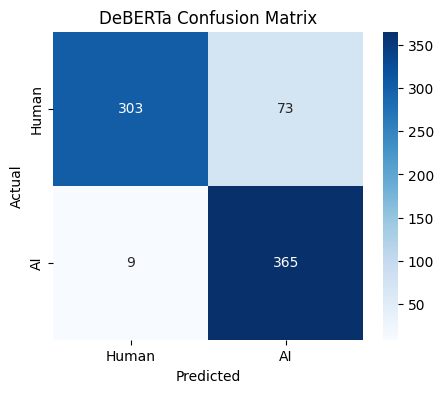

In [13]:
cm = confusion_matrix(y_true, y_pred)

print("\nConfusion Matrix:")
print(cm)

plt.figure(figsize=(5,4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Human", "AI"],
    yticklabels=["Human", "AI"]
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("DeBERTa Confusion Matrix")
plt.show()

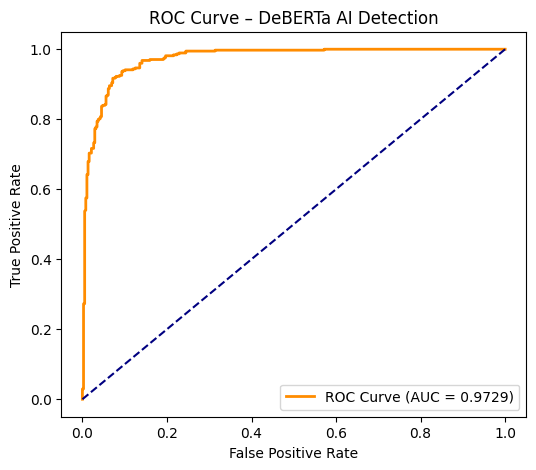

In [14]:
fpr, tpr, _ = roc_curve(y_true, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(
    fpr,
    tpr,
    lw=2,
    color="darkorange",
    label=f"ROC Curve (AUC = {roc_auc:.4f})"
)
plt.plot([0, 1], [0, 1], linestyle="--", color="navy")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – DeBERTa AI Detection")
plt.legend(loc="lower right")
plt.show()